# 02c — Hotspot-Centered Peptide Library

## Obiettivo

Questo notebook costruisce una **libreria di frammenti peptidici naturali corti** attorno agli hotspot energetici FoldX identificati nel notebook **02b**.

Il notebook:

- legge gli output consolidati del notebook 02b;
- ricostruisce la sequenza completa della catena peptidica dal PDB 3NJP;
- genera finestre centrate sugli hotspot con lunghezze configurabili;
- conserva la numerazione reale del PDB;
- identifica tutti gli hotspot e i residui di interfaccia presenti in ogni frammento;
- elimina i duplicati;
- calcola copertura e densità degli hotspot;
- controlla continuità, lunghezza e coerenza;
- esporta la libreria in CSV e JSON.

## Posizione nella pipeline

```text
01 / 01b → 02b FoldX → 02c libreria di frammenti → 02d ranking strutturale/energetico
```

Questo notebook **non esegue ancora** mutazioni, diffusione, docking Rosetta o CLEAR.


## 1. Dipendenze

Sono richiesti:

```bash
pip install pandas numpy matplotlib biopython
```


In [1]:
from pathlib import Path
from collections import defaultdict
import json
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from Bio.PDB import PDBParser, is_aa
except ImportError as exc:
    raise ImportError(
        "Biopython non è installato. Eseguire: pip install biopython"
    ) from exc

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Ambiente inizializzato correttamente.")

Ambiente inizializzato correttamente.


## 2. Configurazione

Le lunghezze sono dispari affinché l'hotspot possa occupare esattamente la posizione centrale.

La prima esplorazione usa:

```text
7, 9, 11, 13 e 15 residui
```

La finestra di 15 residui corrisponde all'esempio discusso: 7 residui prima, hotspot centrale e 7 residui dopo.


In [2]:
# Struttura e catena di interesse
PDB_ID = "3NJP"
PEPTIDE_CHAIN = "D"

# Criterio energetico già adottato nel notebook 02b
DDG_HOTSPOT_THRESHOLD = 1.5

# Libreria iniziale di peptidi corti
WINDOW_LENGTHS = [7, 9, 11, 13, 15]

# Seed originario selezionato nella pipeline precedente
ORIGINAL_SEED_START = 21
ORIGINAL_SEED_END = 50

# Se True, le finestre che non raggiungono la lunghezza richiesta
# perché vicine a un'estremità della catena vengono escluse.
REQUIRE_FULL_LENGTH_WINDOWS = True

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LIBRARY_DIR = OUTPUT_DIR / "hotspot_centered_library"
LIBRARY_DIR.mkdir(parents=True, exist_ok=True)

INTERFACE_DDG_PATH = OUTPUT_DIR / "interface_residues_with_foldx_ddg.csv"
ENERGETIC_HOTSPOTS_PATH = OUTPUT_DIR / "energetic_hotspots.csv"

print("Cartella di output:", LIBRARY_DIR.resolve())
print("Lunghezze richieste:", WINDOW_LENGTHS)

Cartella di output: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library
Lunghezze richieste: [7, 9, 11, 13, 15]


## 3. Individuazione del PDB 3NJP

Il notebook cerca prima un file locale. Se non lo trova, prova a scaricarlo da RCSB PDB.

La ricerca comprende anche il file già prodotto dal notebook 02b nella cartella FoldX.


In [3]:
candidate_pdb_paths = [
    Path("3njp.pdb"),
    Path("3NJP.pdb"),
    Path("pdb3njp.ent"),
    OUTPUT_DIR / "3njp.pdb",
    OUTPUT_DIR / "3NJP.pdb",
    OUTPUT_DIR / "pdb3njp.ent",
    OUTPUT_DIR / "foldx_buildmodel" / "3NJP_BD_clean.pdb",
    OUTPUT_DIR / "foldx_buildmodel" / "3NJP_BD_clean_Repair.pdb",
    Path("data") / "3njp.pdb",
    Path("data") / "3NJP.pdb",
]

PDB_PATH = next((p for p in candidate_pdb_paths if p.exists()), None)

if PDB_PATH is None:
    PDB_PATH = OUTPUT_DIR / "3NJP.pdb"
    url = "https://files.rcsb.org/download/3NJP.pdb"
    print("PDB locale non trovato. Download da:", url)
    try:
        urllib.request.urlretrieve(url, PDB_PATH)
    except Exception as exc:
        raise FileNotFoundError(
            "Impossibile trovare o scaricare 3NJP.pdb. "
            "Collocare manualmente il file nella cartella corrente o in outputs/."
        ) from exc
else:
    print("PDB locale trovato:", PDB_PATH)

print("PDB utilizzato:", PDB_PATH.resolve())

PDB locale trovato: outputs/3njp.pdb
PDB utilizzato: /Users/robertobruzzese/Desktop/venv/outputs/3njp.pdb


## 4. Caricamento degli output del notebook 02b

File attesi:

- `outputs/interface_residues_with_foldx_ddg.csv`
- `outputs/energetic_hotspots.csv`

Il secondo file può essere ricostruito dal primo, purché siano presenti `ddG_kcal_mol` e la soglia di 1,5 kcal/mol.


In [4]:
if not INTERFACE_DDG_PATH.exists():
    raise FileNotFoundError(
        f"File mancante: {INTERFACE_DDG_PATH}\n"
        "Eseguire prima il notebook 02b nella stessa cartella di lavoro."
    )

interface_ddg = pd.read_csv(INTERFACE_DDG_PATH)

required_interface_cols = {"chain", "resseq", "resname", "ddG_kcal_mol"}
missing = required_interface_cols - set(interface_ddg.columns)
if missing:
    raise ValueError(
        "Il file interface_residues_with_foldx_ddg.csv non contiene le colonne: "
        + ", ".join(sorted(missing))
    )

interface_ddg["chain"] = interface_ddg["chain"].astype(str)
interface_ddg["resseq"] = pd.to_numeric(interface_ddg["resseq"], errors="raise").astype(int)
interface_ddg["ddG_kcal_mol"] = pd.to_numeric(
    interface_ddg["ddG_kcal_mol"], errors="coerce"
)

if "is_energetic_hotspot" not in interface_ddg.columns:
    interface_ddg["is_energetic_hotspot"] = (
        interface_ddg["ddG_kcal_mol"] > DDG_HOTSPOT_THRESHOLD
    )
else:
    # Gestione robusta di True/False letti come stringhe
    interface_ddg["is_energetic_hotspot"] = (
        interface_ddg["is_energetic_hotspot"]
        .astype(str)
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(interface_ddg["ddG_kcal_mol"] > DDG_HOTSPOT_THRESHOLD)
        .astype(bool)
    )

if ENERGETIC_HOTSPOTS_PATH.exists():
    energetic_hotspots = pd.read_csv(ENERGETIC_HOTSPOTS_PATH)
    energetic_hotspots["chain"] = energetic_hotspots["chain"].astype(str)
    energetic_hotspots["resseq"] = pd.to_numeric(
        energetic_hotspots["resseq"], errors="raise"
    ).astype(int)
else:
    warnings.warn(
        f"{ENERGETIC_HOTSPOTS_PATH} non trovato: ricostruzione dal file completo."
    )
    energetic_hotspots = interface_ddg[
        interface_ddg["is_energetic_hotspot"]
    ].copy()

chain_interface = (
    interface_ddg[interface_ddg["chain"] == PEPTIDE_CHAIN]
    .drop_duplicates(["chain", "resseq"])
    .copy()
)

chain_hotspots = (
    energetic_hotspots[energetic_hotspots["chain"] == PEPTIDE_CHAIN]
    .drop_duplicates(["chain", "resseq"])
    .sort_values("resseq")
    .copy()
)

if chain_hotspots.empty:
    raise ValueError(
        f"Nessun hotspot energetico trovato nella catena {PEPTIDE_CHAIN}."
    )

print("Residui di interfaccia nella catena", PEPTIDE_CHAIN, ":", len(chain_interface))
print("Hotspot energetici nella catena", PEPTIDE_CHAIN, ":", len(chain_hotspots))

display(
    chain_hotspots[
        [c for c in ["chain", "resseq", "resname", "ddG_kcal_mol"]
         if c in chain_hotspots.columns]
    ]
)

Residui di interfaccia nella catena D : 31
Hotspot energetici nella catena D : 15


,chain,resseq,resname,ddG_kcal_mol
11,D,12,GLY,2.88259
10,D,13,TYR,3.32989
12,D,15,LEU,2.50159
7,D,16,HIS,2.44148
14,D,21,MET,1.74923
4,D,23,ILE,3.65614
3,D,26,LEU,4.15852
1,D,33,CYS,2.91303
13,D,37,TYR,4.64586
6,D,39,GLY,5.87659


## 5. Ricostruzione della sequenza completa della catena D

La numerazione viene letta direttamente dal PDB. Sono conservati:

- numero del residuo (`resseq`);
- insertion code (`icode`);
- nome a tre lettere;
- codice a una lettera;
- posizione progressiva nella catena.

Questo evita di assumere che `end_resseq - start_resseq + 1` coincida sempre con la lunghezza reale.


In [5]:
AA3_TO_1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

parser = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, str(PDB_PATH))
model = next(structure.get_models())

if PEPTIDE_CHAIN not in model:
    available = [chain.id for chain in model]
    raise KeyError(
        f"Catena {PEPTIDE_CHAIN} non presente nel PDB. Catene disponibili: {available}"
    )

chain = model[PEPTIDE_CHAIN]
sequence_rows = []

for residue in chain:
    if not is_aa(residue, standard=True):
        continue

    resname = residue.get_resname().upper()
    aa1 = AA3_TO_1.get(resname)

    if aa1 is None:
        continue

    hetflag, resseq, icode = residue.id
    sequence_rows.append({
        "chain": PEPTIDE_CHAIN,
        "resseq": int(resseq),
        "icode": str(icode).strip(),
        "resname": resname,
        "aa1": aa1,
    })

full_chain = pd.DataFrame(sequence_rows)

if full_chain.empty:
    raise ValueError(f"Nessun residuo standard trovato nella catena {PEPTIDE_CHAIN}.")

full_chain = (
    full_chain
    .sort_values(["resseq", "icode"])
    .reset_index(drop=True)
)

full_chain["chain_index"] = np.arange(len(full_chain), dtype=int)
full_chain["pdb_position"] = (
    full_chain["chain"]
    + ":"
    + full_chain["resseq"].astype(str)
    + full_chain["icode"].fillna("")
)

full_sequence = "".join(full_chain["aa1"])

print("Lunghezza catena ricostruita:", len(full_chain))
print("Intervallo PDB:", full_chain["resseq"].min(), "-", full_chain["resseq"].max())
print("Sequenza:")
print(full_sequence)

display(full_chain.head(10))

Lunghezza catena ricostruita: 47
Intervallo PDB: 5 - 51
Sequenza:
ECPLSHDGYCLHDGVCMYIEALDKYACNCVVGYIGERCQYRDLKWWE


,chain,resseq,icode,resname,aa1,chain_index,pdb_position
0,D,5,,GLU,E,0,D:5
1,D,6,,CYS,C,1,D:6
2,D,7,,PRO,P,2,D:7
3,D,8,,LEU,L,3,D:8
4,D,9,,SER,S,4,D:9
5,D,10,,HIS,H,5,D:10
6,D,11,,ASP,D,6,D:11
7,D,12,,GLY,G,7,D:12
8,D,13,,TYR,Y,8,D:13
9,D,14,,CYS,C,9,D:14


## 6. Annotazione della sequenza

Ogni residuo viene annotato con:

- appartenenza all'interfaccia;
- stato di hotspot energetico;
- ΔΔG FoldX;
- appartenenza al seed originario D:21–50.


In [6]:
annotation_cols = [
    c for c in [
        "chain", "resseq", "ddG_kcal_mol", "n_contacts",
        "degree", "betweenness", "graph_proxy_score",
        "is_energetic_hotspot"
    ]
    if c in chain_interface.columns
]

annotations = (
    chain_interface[annotation_cols]
    .drop_duplicates(["chain", "resseq"])
    .copy()
)

full_chain = full_chain.merge(
    annotations,
    on=["chain", "resseq"],
    how="left"
)

numeric_cols = [
    "ddG_kcal_mol", "n_contacts", "degree",
    "betweenness", "graph_proxy_score"
]
for col in numeric_cols:
    if col not in full_chain.columns:
        full_chain[col] = 0.0
    full_chain[col] = pd.to_numeric(full_chain[col], errors="coerce").fillna(0.0)

if "is_energetic_hotspot" not in full_chain.columns:
    full_chain["is_energetic_hotspot"] = (
        full_chain["ddG_kcal_mol"] > DDG_HOTSPOT_THRESHOLD
    )
else:
    full_chain["is_energetic_hotspot"] = (
        full_chain["is_energetic_hotspot"].fillna(False).astype(bool)
    )

full_chain["is_interface"] = full_chain["resseq"].isin(
    set(chain_interface["resseq"])
)

full_chain["within_original_seed"] = full_chain["resseq"].between(
    ORIGINAL_SEED_START, ORIGINAL_SEED_END
)

hotspot_resseqs = set(
    full_chain.loc[full_chain["is_energetic_hotspot"], "resseq"].astype(int)
)
interface_resseqs = set(
    full_chain.loc[full_chain["is_interface"], "resseq"].astype(int)
)
seed_hotspot_resseqs = {
    x for x in hotspot_resseqs
    if ORIGINAL_SEED_START <= x <= ORIGINAL_SEED_END
}

TOTAL_CHAIN_HOTSPOTS = len(hotspot_resseqs)
TOTAL_SEED_HOTSPOTS = len(seed_hotspot_resseqs)
TOTAL_CHAIN_INTERFACE_RESIDUES = len(interface_resseqs)

print("Hotspot totali catena D:", TOTAL_CHAIN_HOTSPOTS)
print("Hotspot nel seed D:21–50:", TOTAL_SEED_HOTSPOTS)
print("Residui di interfaccia catena D:", TOTAL_CHAIN_INTERFACE_RESIDUES)

display(
    full_chain[
        [
            "chain_index", "pdb_position", "resname", "aa1",
            "is_interface", "is_energetic_hotspot", "ddG_kcal_mol",
            "within_original_seed"
        ]
    ]
)

Hotspot totali catena D: 15
Hotspot nel seed D:21–50: 11
Residui di interfaccia catena D: 31


/var/folders/0m/d24nsv4519382b4zmd5t19cw0000gn/T/ipykernel_90834/1601360171.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_chain["is_energetic_hotspot"].fillna(False).astype(bool)


,chain_index,pdb_position,resname,aa1,is_interface,is_energetic_hotspot,ddG_kcal_mol,within_original_seed
0,0,D:5,GLU,E,False,False,0.000000,False
1,1,D:6,CYS,C,False,False,0.000000,False
2,2,D:7,PRO,P,False,False,0.000000,False
3,3,D:8,LEU,L,False,False,0.000000,False
4,4,D:9,SER,S,True,False,-0.157124,False
5,5,D:10,HIS,H,True,False,0.885896,False
6,6,D:11,ASP,D,True,False,0.424304,False
7,7,D:12,GLY,G,True,True,2.882590,False
8,8,D:13,TYR,Y,True,True,3.329890,False
9,9,D:14,CYS,C,False,False,0.000000,False


## 7. Controlli preliminari sui dati

Il notebook verifica che:

- gli hotspot del CSV esistano nella sequenza PDB;
- non vi siano duplicati nella numerazione della catena;
- le lunghezze richieste siano interi dispari positivi.


In [7]:
# 1. Duplicati di posizione PDB
duplicated_positions = full_chain.duplicated(["chain", "resseq", "icode"], keep=False)
if duplicated_positions.any():
    display(full_chain[duplicated_positions])
    raise ValueError("Sono presenti posizioni PDB duplicate nella catena ricostruita.")

# 2. Hotspot presenti nel PDB
pdb_resseqs = set(full_chain["resseq"].astype(int))
missing_hotspots = sorted(set(chain_hotspots["resseq"].astype(int)) - pdb_resseqs)

if missing_hotspots:
    raise ValueError(
        "I seguenti hotspot FoldX non sono presenti nella catena PDB ricostruita: "
        + ", ".join(map(str, missing_hotspots))
    )

# 3. Lunghezze valide
if not WINDOW_LENGTHS:
    raise ValueError("WINDOW_LENGTHS è vuoto.")

invalid_lengths = [
    L for L in WINDOW_LENGTHS
    if not isinstance(L, int) or L <= 0 or L % 2 == 0
]
if invalid_lengths:
    raise ValueError(
        "Le lunghezze devono essere interi positivi dispari. Valori non validi: "
        + str(invalid_lengths)
    )

print("Controlli preliminari superati.")

Controlli preliminari superati.


## 8. Generazione delle finestre centrate sugli hotspot

Per ogni hotspot e per ogni lunghezza `L`:

```text
(L-1)/2 residui prima + hotspot + (L-1)/2 residui dopo
```

Le finestre vengono costruite in base all'ordine reale dei residui nel PDB, non mediante semplice aritmetica sulla numerazione.


In [8]:
raw_fragment_rows = []

hotspot_indices = full_chain.index[
    full_chain["is_energetic_hotspot"]
].tolist()

for center_idx in hotspot_indices:
    center_row = full_chain.loc[center_idx]
    center_resseq = int(center_row["resseq"])
    center_label = f"{PEPTIDE_CHAIN}:{center_row['aa1']}{center_resseq}{center_row['icode']}"

    for requested_length in WINDOW_LENGTHS:
        half = requested_length // 2
        start_idx = center_idx - half
        end_idx_exclusive = center_idx + half + 1

        is_truncated = (
            start_idx < 0 or end_idx_exclusive > len(full_chain)
        )

        if is_truncated and REQUIRE_FULL_LENGTH_WINDOWS:
            continue

        clipped_start = max(0, start_idx)
        clipped_end = min(len(full_chain), end_idx_exclusive)
        window = full_chain.iloc[clipped_start:clipped_end].copy()

        actual_length = len(window)
        if actual_length == 0:
            continue

        contains_center = bool(
            (window["resseq"] == center_resseq).any()
        )

        hotspot_window = window[window["is_energetic_hotspot"]].copy()
        interface_window = window[window["is_interface"]].copy()

        hotspot_labels = [
            f"{PEPTIDE_CHAIN}:{r.aa1}{int(r.resseq)}{r.icode}"
            for r in hotspot_window.itertuples()
        ]
        interface_labels = [
            f"{PEPTIDE_CHAIN}:{r.aa1}{int(r.resseq)}{r.icode}"
            for r in interface_window.itertuples()
        ]

        sequence = "".join(window["aa1"].tolist())
        n_hotspots = len(hotspot_window)
        n_interface = len(interface_window)

        raw_fragment_rows.append({
            "chain": PEPTIDE_CHAIN,
            "start_chain_index": int(window["chain_index"].iloc[0]),
            "end_chain_index": int(window["chain_index"].iloc[-1]),
            "start_resseq": int(window["resseq"].iloc[0]),
            "start_icode": str(window["icode"].iloc[0]),
            "end_resseq": int(window["resseq"].iloc[-1]),
            "end_icode": str(window["icode"].iloc[-1]),
            "requested_length": int(requested_length),
            "length": int(actual_length),
            "sequence": sequence,
            "center_hotspot": center_label,
            "center_hotspot_resseq": center_resseq,
            "center_position_in_fragment_1based": int(
                center_idx - clipped_start + 1
            ),
            "hotspot_positions": ";".join(hotspot_labels),
            "hotspot_resseqs": ";".join(
                map(str, hotspot_window["resseq"].astype(int).tolist())
            ),
            "n_hotspots": int(n_hotspots),
            "interface_positions": ";".join(interface_labels),
            "interface_resseqs": ";".join(
                map(str, interface_window["resseq"].astype(int).tolist())
            ),
            "n_interface_residues": int(n_interface),
            "ddG_sum_kcal_mol": float(hotspot_window["ddG_kcal_mol"].sum()),
            "ddG_mean_hotspots_kcal_mol": (
                float(hotspot_window["ddG_kcal_mol"].mean())
                if n_hotspots > 0 else 0.0
            ),
            "hotspot_coverage_chain": (
                n_hotspots / TOTAL_CHAIN_HOTSPOTS
                if TOTAL_CHAIN_HOTSPOTS else np.nan
            ),
            "hotspot_coverage_original_seed": (
                len(
                    set(hotspot_window["resseq"].astype(int))
                    & seed_hotspot_resseqs
                ) / TOTAL_SEED_HOTSPOTS
                if TOTAL_SEED_HOTSPOTS else np.nan
            ),
            "hotspot_density": (
                n_hotspots / actual_length if actual_length else np.nan
            ),
            "interface_fraction": (
                n_interface / actual_length if actual_length else np.nan
            ),
            "within_original_seed": bool(
                window["resseq"].between(
                    ORIGINAL_SEED_START, ORIGINAL_SEED_END
                ).all()
            ),
            "contains_center_hotspot": contains_center,
            "is_truncated": bool(is_truncated),
            "source_type": "natural_centered_window",
        })

raw_fragments = pd.DataFrame(raw_fragment_rows)

if raw_fragments.empty:
    raise ValueError(
        "Nessuna finestra generata. Verificare lunghezze, catena e hotspot."
    )

print("Finestre grezze generate:", len(raw_fragments))
display(raw_fragments.head(10))

Finestre grezze generate: 71


,chain,start_chain_index,end_chain_index,start_resseq,start_icode,end_resseq,end_icode,requested_length,length,sequence,center_hotspot,center_hotspot_resseq,center_position_in_fragment_1based,hotspot_positions,hotspot_resseqs,n_hotspots,interface_positions,interface_resseqs,n_interface_residues,ddG_sum_kcal_mol,ddG_mean_hotspots_kcal_mol,hotspot_coverage_chain,hotspot_coverage_original_seed,hotspot_density,interface_fraction,within_original_seed,contains_center_hotspot,is_truncated,source_type
0,D,4,10,9,,15,,7,7,SHDGYCL,D:G12,12,4,D:G12;D:Y13;D:L15,12;13;15,3,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15,9;10;11;12;13;15,6,8.71407,2.904690,0.200000,0.0,0.428571,0.857143,False,True,False,natural_centered_window
1,D,3,11,8,,16,,9,9,LSHDGYCLH,D:G12,12,5,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,9;10;11;12;13;15;16,7,11.15555,2.788887,0.266667,0.0,0.444444,0.777778,False,True,False,natural_centered_window
2,D,2,12,7,,17,,11,11,PLSHDGYCLHD,D:G12,12,6,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,9;10;11;12;13;15;16,7,11.15555,2.788887,0.266667,0.0,0.363636,0.636364,False,True,False,natural_centered_window
3,D,1,13,6,,18,,13,13,CPLSHDGYCLHDG,D:G12,12,7,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,9;10;11;12;13;15;16,7,11.15555,2.788887,0.266667,0.0,0.307692,0.538462,False,True,False,natural_centered_window
4,D,0,14,5,,19,,15,15,ECPLSHDGYCLHDGV,D:G12,12,8,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,9;10;11;12;13;15;16,7,11.15555,2.788887,0.266667,0.0,0.266667,0.466667,False,True,False,natural_centered_window
5,D,5,11,10,,16,,7,7,HDGYCLH,D:Y13,13,4,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,10;11;12;13;15;16,6,11.15555,2.788887,0.266667,0.0,0.571429,0.857143,False,True,False,natural_centered_window
6,D,4,12,9,,17,,9,9,SHDGYCLHD,D:Y13,13,5,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,9;10;11;12;13;15;16,7,11.15555,2.788887,0.266667,0.0,0.444444,0.777778,False,True,False,natural_centered_window
7,D,3,13,8,,18,,11,11,LSHDGYCLHDG,D:Y13,13,6,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,9;10;11;12;13;15;16,7,11.15555,2.788887,0.266667,0.0,0.363636,0.636364,False,True,False,natural_centered_window
8,D,2,14,7,,19,,13,13,PLSHDGYCLHDGV,D:Y13,13,7,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,9;10;11;12;13;15;16,7,11.15555,2.788887,0.266667,0.0,0.307692,0.538462,False,True,False,natural_centered_window
9,D,1,15,6,,20,,15,15,CPLSHDGYCLHDGVC,D:Y13,13,8,D:G12;D:Y13;D:L15;D:H16,12;13;15;16,4,D:S9;D:H10;D:D11;D:G12;D:Y13;D:L15;D:H16,9;10;11;12;13;15;16,7,11.15555,2.788887,0.266667,0.0,0.266667,0.466667,False,True,False,natural_centered_window


## 9. Deduplicazione

Hotspot vicini possono generare lo stesso intervallo peptidico. Le finestre identiche vengono unite.

Per ogni frammento deduplicato vengono conservati tutti gli hotspot che lo hanno generato nella colonna `generation_centers`.


In [9]:
dedup_key = [
    "chain",
    "start_chain_index",
    "end_chain_index",
    "start_resseq",
    "start_icode",
    "end_resseq",
    "end_icode",
    "sequence",
]

def join_unique(values):
    items = []
    for value in values:
        if pd.isna(value):
            continue
        for item in str(value).split(";"):
            item = item.strip()
            if item and item not in items:
                items.append(item)
    return ";".join(items)

aggregation = {
    "requested_length": "first",
    "length": "first",
    "center_hotspot": join_unique,
    "center_hotspot_resseq": lambda x: join_unique(map(str, x)),
    "center_position_in_fragment_1based": lambda x: join_unique(map(str, x)),
    "hotspot_positions": "first",
    "hotspot_resseqs": "first",
    "n_hotspots": "first",
    "interface_positions": "first",
    "interface_resseqs": "first",
    "n_interface_residues": "first",
    "ddG_sum_kcal_mol": "first",
    "ddG_mean_hotspots_kcal_mol": "first",
    "hotspot_coverage_chain": "first",
    "hotspot_coverage_original_seed": "first",
    "hotspot_density": "first",
    "interface_fraction": "first",
    "within_original_seed": "first",
    "contains_center_hotspot": "all",
    "is_truncated": "any",
    "source_type": "first",
}

fragment_library = (
    raw_fragments
    .groupby(dedup_key, as_index=False, dropna=False)
    .agg(aggregation)
    .rename(columns={
        "center_hotspot": "generation_centers",
        "center_hotspot_resseq": "generation_center_resseqs",
        "center_position_in_fragment_1based": "generation_center_positions_1based",
    })
)

fragment_library["n_generation_centers"] = (
    fragment_library["generation_centers"]
    .apply(lambda x: len(str(x).split(";")) if str(x) else 0)
)

# Un ranking descrittivo, NON energetico di docking:
# privilegia hotspot, densità e copertura dell'interfaccia,
# con una lieve preferenza per frammenti più corti a parità di contenuto.
fragment_library["descriptive_priority_score"] = (
    3.0 * fragment_library["n_hotspots"]
    + 2.0 * fragment_library["hotspot_density"]
    + 1.5 * fragment_library["interface_fraction"]
    + 0.10 * fragment_library["ddG_sum_kcal_mol"]
    - 0.02 * fragment_library["length"]
)

fragment_library = (
    fragment_library
    .sort_values(
        [
            "n_hotspots",
            "hotspot_density",
            "interface_fraction",
            "ddG_sum_kcal_mol",
            "length",
        ],
        ascending=[False, False, False, False, True],
    )
    .reset_index(drop=True)
)

fragment_library.insert(
    0,
    "fragment_id",
    [f"F{i:04d}" for i in range(1, len(fragment_library) + 1)]
)

preferred_column_order = [
    "fragment_id",
    "chain",
    "start_resseq",
    "start_icode",
    "end_resseq",
    "end_icode",
    "length",
    "sequence",
    "generation_centers",
    "generation_center_resseqs",
    "generation_center_positions_1based",
    "n_generation_centers",
    "hotspot_positions",
    "hotspot_resseqs",
    "n_hotspots",
    "interface_positions",
    "interface_resseqs",
    "n_interface_residues",
    "ddG_sum_kcal_mol",
    "ddG_mean_hotspots_kcal_mol",
    "hotspot_coverage_chain",
    "hotspot_coverage_original_seed",
    "hotspot_density",
    "interface_fraction",
    "within_original_seed",
    "requested_length",
    "contains_center_hotspot",
    "is_truncated",
    "source_type",
    "descriptive_priority_score",
    "start_chain_index",
    "end_chain_index",
]

fragment_library = fragment_library[
    [c for c in preferred_column_order if c in fragment_library.columns]
]

print("Finestre grezze:", len(raw_fragments))
print("Frammenti unici:", len(fragment_library))
print("Duplicati/centri convergenti rimossi:", len(raw_fragments) - len(fragment_library))

display(fragment_library.head(25))

Finestre grezze: 71
Frammenti unici: 71
Duplicati/centri convergenti rimossi: 0


,fragment_id,chain,start_resseq,start_icode,end_resseq,end_icode,length,sequence,generation_centers,generation_center_resseqs,generation_center_positions_1based,n_generation_centers,hotspot_positions,hotspot_resseqs,n_hotspots,interface_positions,interface_resseqs,n_interface_residues,ddG_sum_kcal_mol,ddG_mean_hotspots_kcal_mol,hotspot_coverage_chain,hotspot_coverage_original_seed,hotspot_density,interface_fraction,within_original_seed,requested_length,contains_center_hotspot,is_truncated,source_type,descriptive_priority_score,start_chain_index,end_chain_index
0,F0001,D,37,,49,,13,YIGERCQYRDLKW,D:Q43,43,7,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48;D:W49,37;38;39;40;41;43;44;45;46;47;48;49,12,27.68977,3.955681,0.466667,0.636364,0.538462,0.923077,True,13,True,False,natural_centered_window,25.970515,32,44
1,F0002,D,35,,47,,13,VGYIGERCQYRDL,D:R41,41,7,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:V35;D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47,35;37;38;39;40;41;43;44;45;46;47,11,27.68977,3.955681,0.466667,0.636364,0.538462,0.846154,True,13,True,False,natural_centered_window,25.855131,30,42
2,F0003,D,33,,45,,13,CVVGYIGERCQYR,D:G39,39,7,1,D:C33;D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,33;37;39;41;43;44;45,7,D:C33;D:V35;D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45,33;35;37;38;39;40;41;43;44;45,10,27.05909,3.865584,0.466667,0.636364,0.538462,0.769231,True,13,True,False,natural_centered_window,25.676678,28,40
3,F0004,D,37,,51,,15,YIGERCQYRDLKWWE,D:Y44,44,8,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48;D:W49;D:W50;D:E51,37;38;39;40;41;43;44;45;46;47;48;49;50;51,14,27.68977,3.955681,0.466667,0.636364,0.466667,0.933333,False,15,True,False,natural_centered_window,25.802310,32,46
4,F0005,D,36,,50,,15,GYIGERCQYRDLKWW,D:Q43,43,8,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48;D:W49;D:W50,37;38;39;40;41;43;44;45;46;47;48;49;50,13,27.68977,3.955681,0.466667,0.636364,0.466667,0.866667,True,15,True,False,natural_centered_window,25.702310,31,45
5,F0006,D,34,,48,,15,VVGYIGERCQYRDLK,D:R41,41,8,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,37;39;41;43;44;45;47,7,D:V35;D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48,35;37;38;39;40;41;43;44;45;46;47;48,12,27.68977,3.955681,0.466667,0.636364,0.466667,0.800000,True,15,True,False,natural_centered_window,25.602310,29,43
6,F0007,D,32,,46,,15,NCVVGYIGERCQYRD,D:G39,39,8,1,D:C33;D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,33;37;39;41;43;44;45,7,D:N32;D:C33;D:V35;D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46,32;33;35;37;38;39;40;41;43;44;45;46,12,27.05909,3.865584,0.466667,0.636364,0.466667,0.800000,True,15,True,False,natural_centered_window,25.539242,27,41
7,F0008,D,37,,45,,9,YIGERCQYR,D:R41,41,5,1,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,37;39;41;43;44;45,6,D:Y37;D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45,37;38;39;40;41;43;44;45,8,24.14606,4.024343,0.400000,0.545455,0.666667,0.888889,True,9,True,False,natural_centered_window,22.901273,32,40
8,F0009,D,39,,47,,9,GERCQYRDL,D:Q43,43,5,1,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,39;41;43;44;45;47,6,D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47,39;40;41;43;44;45;46;47,8,23.04391,3.840652,0.400000,0.545455,0.666667,0.888889,True,9,True,False,natural_centered_window,22.791058,34,42
9,F0010,D,38,,48,,11,IGERCQYRDLK,D:Q43,43,6,1,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,39;41;43;44;45;47,6,D:I38;D:G39;D:E40;D:R41;D:Q43;D:Y44;D:R45;D:D46;D:L47;D:K48,38;39;40;41;43;44;45;46;47;48,10,23.04391,3.840652,0.400000,0.545455,0.545455,0.909091,True,11,True,False,natural_centered_window,22.538936,33,43


## 10. Controlli di qualità della libreria

Questi controlli non stabiliscono che un peptide leghi bene. Verificano soltanto la correttezza computazionale della generazione.


In [10]:
quality_checks = []

# Lunghezza dichiarata = lunghezza della sequenza
length_match = (
    fragment_library["length"]
    == fragment_library["sequence"].str.len()
).all()
quality_checks.append({
    "check": "length_equals_sequence_length",
    "passed": bool(length_match),
})

# Tutte le finestre contengono almeno un hotspot
has_hotspot = (fragment_library["n_hotspots"] >= 1).all()
quality_checks.append({
    "check": "all_fragments_contain_hotspot",
    "passed": bool(has_hotspot),
})

# Le finestre generate contengono il centro previsto
contains_center = fragment_library["contains_center_hotspot"].all()
quality_checks.append({
    "check": "all_fragments_contain_generation_center",
    "passed": bool(contains_center),
})

# Nessun duplicato residuo
no_duplicates = ~fragment_library.duplicated(
    ["chain", "start_chain_index", "end_chain_index", "sequence"]
).any()
quality_checks.append({
    "check": "no_duplicate_fragments",
    "passed": bool(no_duplicates),
})

# Finestre complete se richiesto
full_lengths_ok = True
if REQUIRE_FULL_LENGTH_WINDOWS:
    full_lengths_ok = (
        fragment_library["length"]
        == fragment_library["requested_length"]
    ).all()
quality_checks.append({
    "check": "requested_lengths_respected",
    "passed": bool(full_lengths_ok),
})

# Il centro deve occupare la posizione centrale.
def center_positions_are_valid(row):
    expected = row["length"] // 2 + 1
    observed = {
        int(x) for x in str(row["generation_center_positions_1based"]).split(";")
        if str(x).strip()
    }
    return observed == {expected}

centered_ok = fragment_library.apply(
    center_positions_are_valid, axis=1
).all()
quality_checks.append({
    "check": "hotspots_are_centered",
    "passed": bool(centered_ok),
})

quality_df = pd.DataFrame(quality_checks)
display(quality_df)

if not quality_df["passed"].all():
    failed = quality_df.loc[~quality_df["passed"], "check"].tolist()
    raise AssertionError("Controlli falliti: " + ", ".join(failed))

print("Tutti i controlli di qualità sono stati superati.")

,check,passed
0,length_equals_sequence_length,True
1,all_fragments_contain_hotspot,True
2,all_fragments_contain_generation_center,True
3,no_duplicate_fragments,True
4,requested_lengths_respected,True
5,hotspots_are_centered,True


Tutti i controlli di qualità sono stati superati.


## 11. Tabella riepilogativa per lunghezza

La tabella consente di confrontare:

- numero di frammenti unici;
- quantità media e massima di hotspot;
- densità media degli hotspot;
- frazione media di residui di interfaccia;
- somma media del ΔΔG degli hotspot contenuti.

Queste sono metriche descrittive, non una prova di binding.


In [11]:
fragment_summary = (
    fragment_library
    .groupby("length", as_index=False)
    .agg(
        n_unique_fragments=("fragment_id", "count"),
        mean_hotspots=("n_hotspots", "mean"),
        max_hotspots=("n_hotspots", "max"),
        mean_hotspot_density=("hotspot_density", "mean"),
        max_hotspot_density=("hotspot_density", "max"),
        mean_interface_fraction=("interface_fraction", "mean"),
        max_interface_fraction=("interface_fraction", "max"),
        mean_ddG_sum_kcal_mol=("ddG_sum_kcal_mol", "mean"),
        max_ddG_sum_kcal_mol=("ddG_sum_kcal_mol", "max"),
        n_within_original_seed=("within_original_seed", "sum"),
    )
    .sort_values("length")
    .reset_index(drop=True)
)

display(fragment_summary)

,length,n_unique_fragments,mean_hotspots,max_hotspots,mean_hotspot_density,max_hotspot_density,mean_interface_fraction,max_interface_fraction,mean_ddG_sum_kcal_mol,max_ddG_sum_kcal_mol,n_within_original_seed
0,7,15,3.133333,5,0.447619,0.714286,0.714286,1.000000,10.694188,17.49739,9
1,9,15,3.933333,6,0.437037,0.666667,0.711111,1.000000,13.724333,24.14606,8
2,11,14,4.357143,6,0.396104,0.545455,0.688312,0.909091,15.269854,24.14606,8
3,13,14,5.000000,7,0.384615,0.538462,0.681319,0.923077,17.528781,27.68977,6
4,15,13,5.384615,7,0.358974,0.466667,0.656410,0.933333,18.734210,27.68977,5


## 12. Visualizzazioni descrittive

I grafici mostrano come il contenuto di hotspot e di residui di interfaccia varia con la lunghezza del frammento.


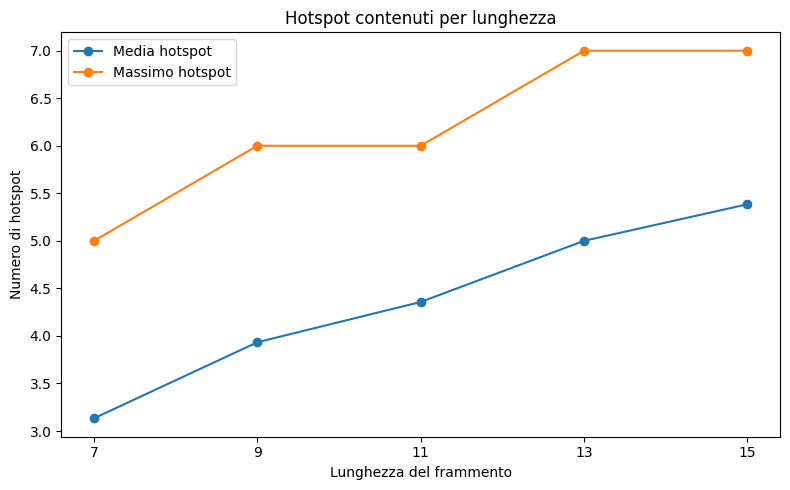

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(
    fragment_summary["length"],
    fragment_summary["mean_hotspots"],
    marker="o",
    label="Media hotspot",
)
plt.plot(
    fragment_summary["length"],
    fragment_summary["max_hotspots"],
    marker="o",
    label="Massimo hotspot",
)
plt.xlabel("Lunghezza del frammento")
plt.ylabel("Numero di hotspot")
plt.title("Hotspot contenuti per lunghezza")
plt.xticks(fragment_summary["length"])
plt.legend()
plt.tight_layout()
plt.savefig(
    LIBRARY_DIR / "hotspots_by_fragment_length.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

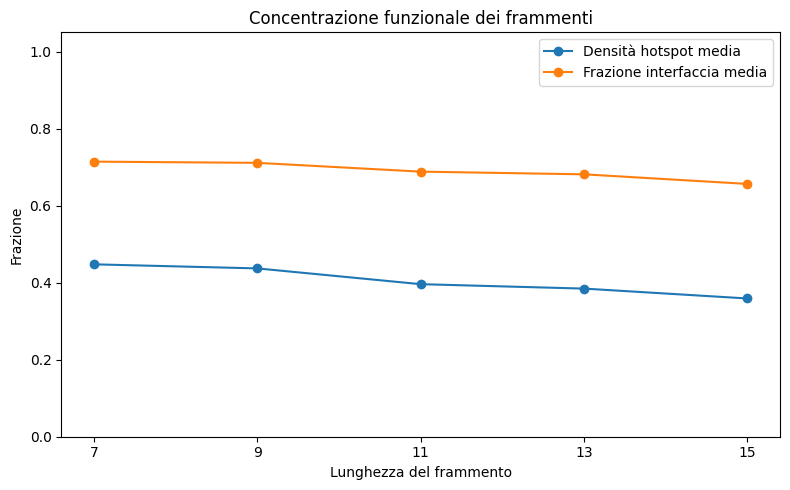

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    fragment_summary["length"],
    fragment_summary["mean_hotspot_density"],
    marker="o",
    label="Densità hotspot media",
)
plt.plot(
    fragment_summary["length"],
    fragment_summary["mean_interface_fraction"],
    marker="o",
    label="Frazione interfaccia media",
)
plt.xlabel("Lunghezza del frammento")
plt.ylabel("Frazione")
plt.title("Concentrazione funzionale dei frammenti")
plt.xticks(fragment_summary["length"])
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(
    LIBRARY_DIR / "fragment_density_and_interface_fraction.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 13. Migliori frammenti secondo criteri descrittivi

La seguente visualizzazione serve soltanto a individuare candidati da inviare al notebook 02d.

**Non va interpretata come un ranking definitivo di affinità.**


In [14]:
top_columns = [
    "fragment_id",
    "sequence",
    "start_resseq",
    "end_resseq",
    "length",
    "hotspot_positions",
    "n_hotspots",
    "n_interface_residues",
    "hotspot_density",
    "interface_fraction",
    "ddG_sum_kcal_mol",
    "hotspot_coverage_chain",
    "hotspot_coverage_original_seed",
    "within_original_seed",
    "descriptive_priority_score",
]

top_fragments = (
    fragment_library
    .sort_values(
        [
            "descriptive_priority_score",
            "n_hotspots",
            "hotspot_density",
            "length",
        ],
        ascending=[False, False, False, True],
    )
    .head(20)
)

display(top_fragments[top_columns])

,fragment_id,sequence,start_resseq,end_resseq,length,hotspot_positions,n_hotspots,n_interface_residues,hotspot_density,interface_fraction,ddG_sum_kcal_mol,hotspot_coverage_chain,hotspot_coverage_original_seed,within_original_seed,descriptive_priority_score
0,F0001,YIGERCQYRDLKW,37,49,13,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,7,12,0.538462,0.923077,27.68977,0.466667,0.636364,True,25.970515
1,F0002,VGYIGERCQYRDL,35,47,13,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,7,11,0.538462,0.846154,27.68977,0.466667,0.636364,True,25.855131
3,F0004,YIGERCQYRDLKWWE,37,51,15,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,7,14,0.466667,0.933333,27.68977,0.466667,0.636364,False,25.802310
4,F0005,GYIGERCQYRDLKWW,36,50,15,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,7,13,0.466667,0.866667,27.68977,0.466667,0.636364,True,25.702310
2,F0003,CVVGYIGERCQYR,33,45,13,D:C33;D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,7,10,0.538462,0.769231,27.05909,0.466667,0.636364,True,25.676678
5,F0006,VVGYIGERCQYRDLK,34,48,15,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,7,12,0.466667,0.800000,27.68977,0.466667,0.636364,True,25.602310
6,F0007,NCVVGYIGERCQYRD,32,46,15,D:C33;D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,7,12,0.466667,0.800000,27.05909,0.466667,0.636364,True,25.539242
7,F0008,YIGERCQYR,37,45,9,D:Y37;D:G39;D:R41;D:Q43;D:Y44;D:R45,6,8,0.666667,0.888889,24.14606,0.400000,0.545455,True,22.901273
8,F0009,GERCQYRDL,39,47,9,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,6,8,0.666667,0.888889,23.04391,0.400000,0.545455,True,22.791058
9,F0010,IGERCQYRDLK,38,48,11,D:G39;D:R41;D:Q43;D:Y44;D:R45;D:L47,6,10,0.545455,0.909091,23.04391,0.400000,0.545455,True,22.538936


## 14. Esportazione

Output principali:

```text
outputs/hotspot_centered_library/hotspot_centered_fragment_library.csv
outputs/hotspot_centered_library/hotspot_centered_fragment_library.json
outputs/hotspot_centered_library/fragment_library_summary.csv
outputs/hotspot_centered_library/top_fragments_descriptive.csv
outputs/hotspot_centered_library/full_chain_annotated.csv
outputs/hotspot_centered_library/library_metadata.json
```


In [15]:
LIBRARY_CSV = LIBRARY_DIR / "hotspot_centered_fragment_library.csv"
LIBRARY_JSON = LIBRARY_DIR / "hotspot_centered_fragment_library.json"
SUMMARY_CSV = LIBRARY_DIR / "fragment_library_summary.csv"
TOP_CSV = LIBRARY_DIR / "top_fragments_descriptive.csv"
ANNOTATED_CHAIN_CSV = LIBRARY_DIR / "full_chain_annotated.csv"
QUALITY_CSV = LIBRARY_DIR / "quality_checks.csv"
METADATA_JSON = LIBRARY_DIR / "library_metadata.json"

fragment_library.to_csv(LIBRARY_CSV, index=False)
fragment_library.to_json(
    LIBRARY_JSON,
    orient="records",
    indent=2,
)
fragment_summary.to_csv(SUMMARY_CSV, index=False)
top_fragments.to_csv(TOP_CSV, index=False)
full_chain.to_csv(ANNOTATED_CHAIN_CSV, index=False)
quality_df.to_csv(QUALITY_CSV, index=False)

metadata = {
    "pdb_id": PDB_ID,
    "pdb_path": str(PDB_PATH),
    "peptide_chain": PEPTIDE_CHAIN,
    "ddg_hotspot_threshold_kcal_mol": DDG_HOTSPOT_THRESHOLD,
    "window_lengths": WINDOW_LENGTHS,
    "require_full_length_windows": REQUIRE_FULL_LENGTH_WINDOWS,
    "original_seed": {
        "chain": PEPTIDE_CHAIN,
        "start_resseq": ORIGINAL_SEED_START,
        "end_resseq": ORIGINAL_SEED_END,
    },
    "n_chain_residues": int(len(full_chain)),
    "n_chain_interface_residues": int(TOTAL_CHAIN_INTERFACE_RESIDUES),
    "n_chain_hotspots": int(TOTAL_CHAIN_HOTSPOTS),
    "n_original_seed_hotspots": int(TOTAL_SEED_HOTSPOTS),
    "n_raw_windows": int(len(raw_fragments)),
    "n_unique_fragments": int(len(fragment_library)),
    "interpretation_warning": (
        "The descriptive priority score is not a docking score and does not "
        "demonstrate improved binding."
    ),
}

METADATA_JSON.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

for path in [
    LIBRARY_CSV,
    LIBRARY_JSON,
    SUMMARY_CSV,
    TOP_CSV,
    ANNOTATED_CHAIN_CSV,
    QUALITY_CSV,
    METADATA_JSON,
]:
    print("Salvato:", path.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library/hotspot_centered_fragment_library.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library/hotspot_centered_fragment_library.json
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library/fragment_library_summary.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library/top_fragments_descriptive.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library/full_chain_annotated.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library/quality_checks.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/hotspot_centered_library/library_metadata.json


## 15. Interpretazione corretta dell'output

Il notebook produce una libreria di frammenti che:

- derivano dalla sequenza naturale di 3NJP;
- contengono almeno un hotspot FoldX;
- hanno lunghezze comprese tra 7 e 15 residui;
- sono centrati sugli hotspot;
- conservano informazioni sulla regione di interfaccia.

Il punteggio `descriptive_priority_score` serve esclusivamente a organizzare la libreria. Non dimostra che un frammento:

- sia stabile in soluzione;
- mantenga il folding locale;
- assuma la posa corretta;
- leghi più fortemente la chinasi;
- funzioni come inibitore.

Questi aspetti dovranno essere valutati nel notebook successivo, **02d — Structural and Energetic Ranking**, mediante preparazione strutturale, rilassamento, docking/refinement e scoring energetico.


## 16. Risultato atteso per il passaggio successivo

Il file principale da fornire al notebook 02d è:

```text
outputs/hotspot_centered_library/hotspot_centered_fragment_library.csv
```

Le colonne essenziali sono:

- `fragment_id`
- `sequence`
- `start_resseq`
- `end_resseq`
- `length`
- `hotspot_positions`
- `n_hotspots`
- `interface_positions`
- `n_interface_residues`
- `hotspot_coverage_chain`
- `hotspot_coverage_original_seed`
- `hotspot_density`
- `interface_fraction`
- `ddG_sum_kcal_mol`
- `within_original_seed`
